In [16]:
import json
import re
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.stats import mstats
from xgboost import XGBRegressor
from catboost import CatBoostRegressor, cv, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from PIL import Image
import requests
from io import BytesIO
import boto3
import warnings

warnings.filterwarnings('ignore')

In [17]:
df = pd.read_parquet('/kaggle/input/datasets/ruziksal/cian-offers/clean_dataset.parquet')

# Models

## CatBoost

In [18]:
num_f = ['rooms', 'area_total', 'area_living', 'area_kitchen', 'floor', 'floors_total',
            'construction_year', 'metros_count', 'metros_min_time', 'building_age', 'area_per_room', 'ceiling_height',
            'floor_ratio', 'kitchen_ratio', 'living_ratio', 'has_parking', 'has_elevator', 'is_new_building',
            'elevators_int', 'bathroom_int']
cat_f = ['district', 'flat_type', 'renovation_type', 'parking', 'house_type']

In [19]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

CUDA available: True
GPU count: 2
GPU name: Tesla T4


In [20]:
X = df[num_f + cat_f]
y = df['log_price']

r2_scores = []
mae_scores = []
mape_scores = []
models = []

params = {
    'iterations': 1000,
    'depth': 7,
    'learning_rate': 0.1,
    'verbose': False,
    'l2_leaf_reg': 10,
    'early_stopping_rounds': 50,
    'eval_metric': 'RMSE',
    'loss_function': 'RMSE',
    'random_seed': 42,
    'task_type': 'GPU',
    'devices': '0'
}

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

model = CatBoostRegressor(verbose=False)
for train_index, test_index in kfold.split(y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    train_pool = Pool(X_train, y_train, cat_features=cat_f)
    test_pool = Pool(X_test, y_test, cat_features=cat_f)

    model = CatBoostRegressor(**params)
    model.fit(train_pool, eval_set=test_pool)

    y_pred = model.predict(test_pool)

    y_pred_orig = np.expm1(y_pred)
    y_test_orig = np.expm1(y_test)
    
    r2_scores.append(r2_score(y_test, y_pred))
    mae_scores.append(mean_absolute_error(y_test_orig, y_pred_orig))
    mape_scores.append(mean_absolute_percentage_error(y_test_orig, y_pred_orig) * 100)
    models.append(model)

r2_base = np.mean(r2_scores)
mae_base = np.mean(mae_scores)
mape_base = np.mean(mape_scores)
print("="*60)
print(f"Средний R²: {np.mean(r2_scores):.4f} (+/- {np.std(r2_scores):.4f})")
print(f"Средний MAE: {np.mean(mae_scores):.0f}")
print(f"Средний MAPE: {np.mean(mape_scores):.2f}")
print("="*60)

Средний R²: 0.9128 (+/- 0.0043)
Средний MAE: 9285589
Средний MAPE: 15.82


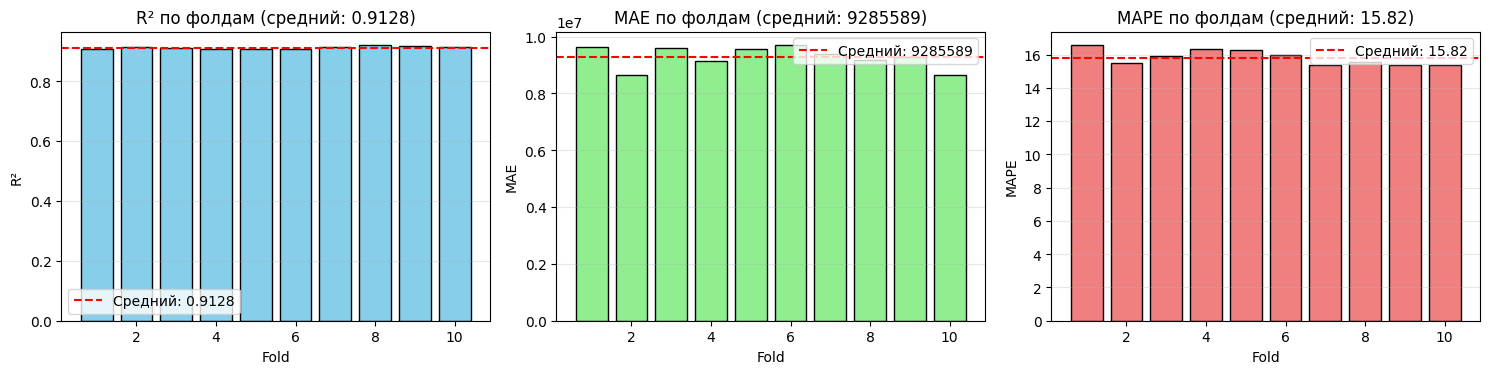

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(range(1, 11), r2_scores, color='skyblue', edgecolor='black')
axes[0].axhline(np.mean(r2_scores), color='red', linestyle='--', label=f'Средний: {np.mean(r2_scores):.4f}')
axes[0].set_title(f'R² по фолдам (средний: {np.mean(r2_scores):.4f})')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('R²')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(range(1, 11), mae_scores, color='lightgreen', edgecolor='black')
axes[1].axhline(np.mean(mae_scores), color='red', linestyle='--', label=f'Средний: {np.mean(mae_scores):.0f}')
axes[1].set_title(f'MAE по фолдам (средний: {np.mean(mae_scores):.0f})')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(range(1, 11), mape_scores, color='lightcoral', edgecolor='black')
axes[2].axhline(np.mean(mape_scores), color='red', linestyle='--', label=f'Средний: {np.mean(mape_scores):.2f}')
axes[2].set_title(f'MAPE по фолдам (средний: {np.mean(mape_scores):.2f})')
axes[2].set_xlabel('Fold')
axes[2].set_ylabel('MAPE')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## CatBoost с встроенным text_features (embeddings)

In [22]:
X = df[num_f + cat_f + ['offer_description']]
y = df['log_price']

r2_scores = []
mae_scores = []
mape_scores = []
models = []

params = {
    'iterations': 1000,
    'depth': 7,
    'learning_rate': 0.1,
    'verbose': False,
    'l2_leaf_reg': 10,
    'early_stopping_rounds': 50,
    'eval_metric': 'RMSE',
    'loss_function': 'RMSE',
    'random_seed': 42,
    'task_type': 'GPU',
    'devices': '0'
}

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

model = CatBoostRegressor(verbose=False)
for train_index, test_index in kfold.split(y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    train_pool = Pool(X_train, y_train, cat_features=cat_f, text_features=['offer_description'])
    test_pool = Pool(X_test, y_test, cat_features=cat_f, text_features=['offer_description'])

    model = CatBoostRegressor(**params)
    model.fit(train_pool, eval_set=test_pool)

    y_pred = model.predict(test_pool)

    y_pred_orig = np.expm1(y_pred)
    y_test_orig = np.expm1(y_test)

    r2_scores.append(r2_score(y_test, y_pred))
    mae_scores.append(mean_absolute_error(y_test_orig, y_pred_orig))
    mape_scores.append(mean_absolute_percentage_error(y_test_orig, y_pred_orig) * 100)
    models.append(model)

r2_text = np.mean(r2_scores)
mae_text = np.mean(mae_scores)
mape_text = np.mean(mape_scores)
print("="*60)
print(f"Средний R²: {np.mean(r2_scores):.4f} (+/- {np.std(r2_scores):.4f})")
print(f"Средний MAE: {np.mean(mae_scores):.0f}")
print(f"Средний MAPE: {np.mean(mape_scores):.2f}")
print("="*60)

Средний R²: 0.9243 (+/- 0.0037)
Средний MAE: 8627599
Средний MAPE: 14.55


## Text embeddings download

In [23]:
text_model = SentenceTransformer('BAAI/bge-m3')

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [24]:
def get_embeddings(texts, batch_size=32):
    embeddings = text_model.encode(texts,
                             show_progress_bar=True,
                             batch_size=batch_size,
                             convert_to_numpy=True)
    return embeddings

In [25]:
description_emb = get_embeddings(df['offer_description'].tolist())
np.save('/kaggle/working/description_embeddings.npy', description_emb)

Batches:   0%|          | 0/798 [00:00<?, ?it/s]

In [26]:
# description_emb = np.load('/content/drive/MyDrive/description_embeddings.npy')

## Text embeddings model

In [27]:
pca = PCA(n_components=100)
text_emb_pca = pca.fit_transform(np.array(description_emb.tolist()))
text_emb_df = pd.DataFrame(text_emb_pca, columns=[f'emb_{i}' for i in range(text_emb_pca.shape[1])], index=df['offer_description'].index)

In [28]:
X_with_text_emb = pd.concat([df[num_f + cat_f], text_emb_df], axis=1)
y = df['log_price']

r2_scores = []
mae_scores = []
mape_scores = []
models = []

params = {
    'iterations': 1000,
    'depth': 7,
    'learning_rate': 0.1,
    'verbose': False,
    'l2_leaf_reg': 10,
    'early_stopping_rounds': 50,
    'eval_metric': 'RMSE',
    'loss_function': 'RMSE',
    'random_seed': 42,
    'task_type': 'GPU',
    'devices': '0'
}

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

model = CatBoostRegressor(verbose=False)
for train_index, test_index in kfold.split(y):
    X_train, X_test = X_with_text_emb.iloc[train_index], X_with_text_emb.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    train_pool = Pool(X_train, y_train, cat_features=cat_f)
    test_pool = Pool(X_test, y_test, cat_features=cat_f)

    model = CatBoostRegressor(**params)
    model.fit(train_pool, eval_set=test_pool)

    y_pred = model.predict(test_pool)

    y_pred_orig = np.expm1(y_pred)
    y_test_orig = np.expm1(y_test)

    r2_scores.append(r2_score(y_test, y_pred))
    mae_scores.append(mean_absolute_error(y_test_orig, y_pred_orig))
    mape_scores.append(mean_absolute_percentage_error(y_test_orig, y_pred_orig) * 100)
    models.append(model)

r2_emb = np.mean(r2_scores)
mae_emb = np.mean(mae_scores)
mape_emb = np.mean(mape_scores)
print("="*60)
print(f"Средний R²: {np.mean(r2_scores):.4f} (+/- {np.std(r2_scores):.4f})")
print(f"Средний MAE: {np.mean(mae_scores):.0f}")
print(f"Средний MAPE: {np.mean(mape_scores):.2f}")
print("="*60)

Средний R²: 0.9274 (+/- 0.0039)
Средний MAE: 8482367
Средний MAPE: 14.26


# Сравнение моделей

             Model        R2           MAE       MAPE
2  Text Embeddings  0.927376  8.482367e+06  14.262377
1    Text Features  0.924257  8.627599e+06  14.554708
0         Baseline  0.912790  9.285589e+06  15.823355


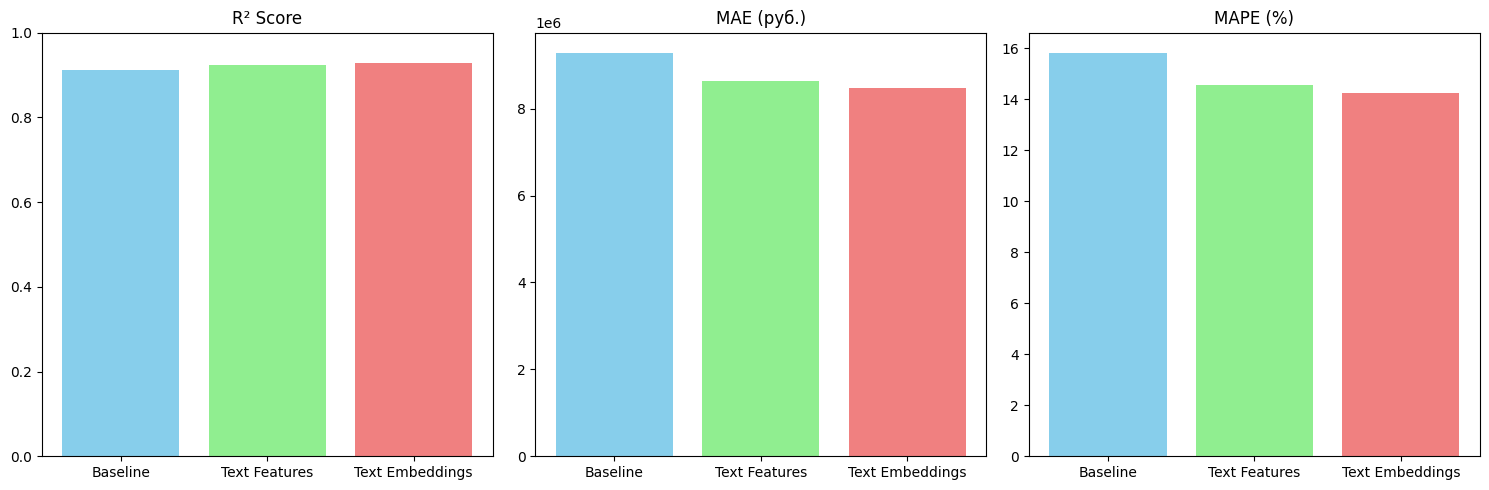

In [29]:
results = pd.DataFrame({
    'Model': ['Baseline', 'Text Features', 'Text Embeddings'],
    'R2': [r2_base, r2_text, r2_emb],
    'MAE': [mae_base, mae_text, mae_emb],
    'MAPE': [mape_base, mape_text, mape_emb]
})

print(results.sort_values('R2', ascending=False))

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(results['Model'], results['R2'], color=['skyblue', 'lightgreen', 'lightcoral'])
axes[0].set_title('R² Score')
axes[0].set_ylim(0, 1)

axes[1].bar(results['Model'], results['MAE'], color=['skyblue', 'lightgreen', 'lightcoral'])
axes[1].set_title('MAE (руб.)')

axes[2].bar(results['Model'], results['MAPE'], color=['skyblue', 'lightgreen', 'lightcoral'])
axes[2].set_title('MAPE (%)')

plt.tight_layout()
plt.show()

In [35]:
import optuna
from optuna.integration import CatBoostPruningCallback

best_model_idx = results['R2'].idxmax()
best_model_name = results.loc[best_model_idx, 'Model']
print(f"Лучшая модель: {best_model_name}")

X_tune, X_val_tune, y_train, y_val = train_test_split(X_with_text_emb, y, test_size=0.2, shuffle=True)

def objective(trial):
    params = {
        'iterations': 1000,
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 30),
        'random_seed': 42,
        'verbose': False,
        'early_stopping_rounds': 50,
        'eval_metric': 'RMSE',
        'loss_function': 'RMSE'
    }
    
    model = CatBoostRegressor(**params)
    model.fit(
        X_tune, y_train,
        cat_features=cat_f,
        eval_set=(X_val_tune, y_val),
        callbacks=[CatBoostPruningCallback(trial, 'RMSE')]
    )
    
    y_pred = model.predict(X_val_tune)
    return r2_score(y_val, y_pred)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Лучшие параметры: {study.best_params}")
print(f"Лучший R²: {study.best_value:.4f}")

[I 2026-04-26 15:05:00,437] A new study created in memory with name: no-name-fa3e2579-eb62-4743-829d-6c337a9a99ea


Лучшая модель: Text Embeddings


[I 2026-04-26 15:05:44,994] Trial 0 finished with value: 0.9309877181129429 and parameters: {'depth': 7, 'learning_rate': 0.14809898959016543, 'l2_leaf_reg': 1.1379013269065745}. Best is trial 0 with value: 0.9309877181129429.
[I 2026-04-26 15:08:08,391] Trial 1 finished with value: 0.9247456511641604 and parameters: {'depth': 9, 'learning_rate': 0.2918249062509939, 'l2_leaf_reg': 16.480968877558425}. Best is trial 0 with value: 0.9309877181129429.
[I 2026-04-26 15:08:52,929] Trial 2 finished with value: 0.9292032051567207 and parameters: {'depth': 7, 'learning_rate': 0.20158067523712508, 'l2_leaf_reg': 21.82276359808349}. Best is trial 0 with value: 0.9309877181129429.
[I 2026-04-26 15:09:13,989] Trial 3 finished with value: 0.92836478652187 and parameters: {'depth': 5, 'learning_rate': 0.11406043993336484, 'l2_leaf_reg': 6.58531923040241}. Best is trial 0 with value: 0.9309877181129429.
[I 2026-04-26 15:09:45,846] Trial 4 finished with value: 0.9258250671085574 and parameters: {'dept

Лучшие параметры: {'depth': 8, 'learning_rate': 0.09683558717843327, 'l2_leaf_reg': 6.0576846773901405}
Лучший R²: 0.9340


In [40]:
final_params = {
    'iterations': 1000,
    'verbose': False,
    'early_stopping_rounds': 50,
    'eval_metric': 'RMSE',
    'loss_function': 'RMSE',
    'random_seed': 42,
    **study.best_params
}

model = CatBoostRegressor(**final_params)
model.fit(
    X_tune, y_train,
    cat_features=cat_f,
    eval_set=(X_val_tune, y_val)
)

y_pred = model.predict(X_val_tune)

y_pred_orig = np.expm1(y_pred)
y_test_orig = np.expm1(y_val)

r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_test_orig, y_pred_orig)
mape = mean_absolute_percentage_error(y_test_orig, y_pred_orig) * 100

print(f'Final metrics: R2={r2:.4f}, MAE={mae:.0f}, MAPE={mape:.2f}')

Final metrics: R2=0.9340, MAE=8095718, MAPE=13.25


In [43]:
final_model = CatBoostRegressor(**final_params)
final_model.fit(
    X_with_text_emb, y,
    cat_features=cat_f,
    eval_set=(X_val_tune, y_val)
)

final_model.save_model('/kaggle/working/best_model.cbm')

feature_config = {
    'num_features': num_f,
    'cat_features': cat_f,
    'emb_columns': emb_columns if 'emb_columns' in dir() else [],
    'best_model_name': best_model_name,
    'target_column': 'log_price',
    'metrics': {
        'r2': r2,
        'mae': mae,
        'mape': mape
    }
}

with open('/kaggle/working/feature_config.json', 'w', encoding='utf-8') as f:
    json.dump(feature_config, f, indent=2, ensure_ascii=False)

print("✅ Модель сохранена как .cbm")
print("✅ Конфигурация сохранена как .json")

✅ Модель сохранена как .cbm
✅ Конфигурация сохранена как .json


In [44]:
!cd /kaggle/working

In [45]:
!ls

best_model.cbm	catboost_info  description_embeddings.npy  feature_config.json


In [49]:
from IPython.display import FileLink
FileLink(r'best_model.cbm')

/kaggle/working/best_model.cbm

In [50]:
FileLink('description_embeddings.npy')

/kaggle/working/description_embeddings.npy